# **בדיקת חיבור לשרת ומעבד**

In [ ]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU'))) # המשך רק אם התקבל 1 או יותר

2026-06-30 11:16:14.389260: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-30 11:16:14.818021: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-30 11:16:14.818115: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-30 11:16:14.818158: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-30 11:16:14.864436: I tensorflow/core/platform/cpu_feature_g

TensorFlow Version: 2.14.0
Num GPUs Available:  1


# **ווידוא זיכרון בשרת**

In [ ]:
# הגדרת ניהול זיכרון GPU למניעת שגיאות OOM
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled!")
    except RuntimeError as e:
        print(e)

GPU Memory Growth Enabled!


# **ייבוא ספריות**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.express as px
import umap

from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("כל הספריות יובאו בהצלחה")

/users/amit.cohen/.local/lib/python3.9/site-packages/numba/core/errors.py:194: UserWarning: Insufficiently recent colorama version found. Numba requires colorama >= 0.3.9
  warnings.warn(msg)
/users/amit.cohen/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


כל הספריות יובאו בהצלחה


# **טעינת המודל**

In [ ]:
# 1. טעינת המודל המנצח מהשרת
FINAL_MODEL_PATH = "vgg16_AUG_LR_combined.h5"
print(f"Loading model: {FINAL_MODEL_PATH}...")
full_model = load_model(FINAL_MODEL_PATH)

# 2. הדפסת מבנה השכבות האחרונות כדי למצוא את שם השכבה הנכונה
print("\n--- Model Layers (Last 5) ---")
for layer in full_model.layers[-5:]:
    print(layer.name)

# 3. חיתוך המודל: ניקח את הקלט המקורי, אבל נבקש את הפלט של השכבה הלפני אחרונה
feature_extractor = Model(inputs=full_model.input,
                          outputs=full_model.get_layer('final_dense_layer').output)

print("\nFeature Extractor is ready")

Loading model: vgg16_AUG_LR_combined.h5...


2026-06-30 11:17:35.875921: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 26202 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:37:00.0, compute capability: 8.0



--- Model Layers (Last 5) ---
block5_pool
flatten_1
final_dense_layer
dropout_1
prediction

Feature Extractor is ready


# **נתיבים והגדרות**

In [ ]:
import os
import numpy as np
import pandas as pd
import umap
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- 1. הגדרת נתיבים ---
BASE_DIR = "/users/amit.cohen/Final_Dataset_Split"
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
TEST_DIR = os.path.join(BASE_DIR, 'test')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# --- 2. יצירת גנרטורים לכל הסטים (Shuffle=False חובה!) ---
print("טוען נתונים...")
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse', shuffle=False)
val_gen = datagen.flow_from_directory(VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse', shuffle=False)
test_gen = datagen.flow_from_directory(TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse', shuffle=False)

class_names = list(train_gen.class_indices.keys())

# --- 3. חילוץ פיצ'רים מכל הסטים ---
print("\nמחלץ פיצ'רים (Extracting Features)...")
train_features = feature_extractor.predict(train_gen, verbose=1)
val_features = feature_extractor.predict(val_gen, verbose=1)
test_features = feature_extractor.predict(test_gen, verbose=1)

# --- 4. שילוב Train ו-Val לצורך אימון ה-UMAP ---
print("\nמשלב Train ו-Val לאימון ה-UMAP...")
train_val_features = np.vstack((train_features, val_features))

# --- 5. הפעלת UMAP (Unsupervised) ---
N_NEIGHBORS = 15
MIN_DIST = 0.1

print(f"מאמן UMAP על Train+Val בלבד (Unsupervised)...")
reducer = umap.UMAP(n_neighbors=N_NEIGHBORS, min_dist=MIN_DIST, random_state=42)

# שים לב: אנחנו משתמשים רק ב-fit (ללא ה-Labels) כדי שהלמידה תהיה Unsupervised!
reducer.fit(train_val_features)

# --- 6. הטלה (Transform) של כל הסטים למרחב הדו-מימדי החדש ---
print("מטיל את כל הסטים (Train, Val, Test) למרחב הדו-מימדי...")
train_embedding = reducer.transform(train_features)
val_embedding = reducer.transform(val_features)
test_embedding = reducer.transform(test_features)

# --- 7. פונקציית עזר לבניית ה-DataFrame ---
def create_umap_df(embedding, generator, set_name):
    # המרת המספרים לשמות המחלקות האמיתיים לצורך צביעה בדיעבד
    labels_names = [class_names[int(lbl)] for lbl in generator.classes]
    return pd.DataFrame({
        'UMAP_X': embedding[:, 0],
        'UMAP_Y': embedding[:, 1],
        'Class': labels_names,
        'Set': set_name,
        'Filename': generator.filenames
    })

# יצירת טבלה לכל סט
df_train = create_umap_df(train_embedding, train_gen, 'Train')
df_val = create_umap_df(val_embedding, val_gen, 'Val')
df_test = create_umap_df(test_embedding, test_gen, 'Test')

# חיבור הכל לטבלה אחת גדולה
final_umap_df = pd.concat([df_train, df_val, df_test], ignore_index=True)

print("\nהנתונים מוכנים לויזואליזציה! הטבלה final_umap_df מכילה את כל המידע.")

טוען נתונים...
Found 672 images belonging to 8 classes.
Found 144 images belonging to 8 classes.
Found 144 images belonging to 8 classes.

מחלץ פיצ'רים (Extracting Features)...


2026-06-30 11:17:49.859934: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2026-06-30 11:17:57.584449: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


 3/21 [===>..........................] - ETA: 0s  

2026-06-30 11:18:01.762495: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


5/5 [==============================] - 1s 145ms/step

משלב Train ו-Val לאימון ה-UMAP...
מאמן UMAP על Train+Val בלבד (Unsupervised)...


/users/amit.cohen/.local/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


מטיל את כל הסטים (Train, Val, Test) למרחב הדו-מימדי...

הנתונים מוכנים לויזואליזציה! הטבלה final_umap_df מכילה את כל המידע.


# **UMAP VISUALIZATION**

✅ נשמר קובץ אינטראקטיבי מעודכן: UMAP_Interactive_Final.html
✅ נשמרה תמונת פוסטר: UMAP_Poster_Final.png


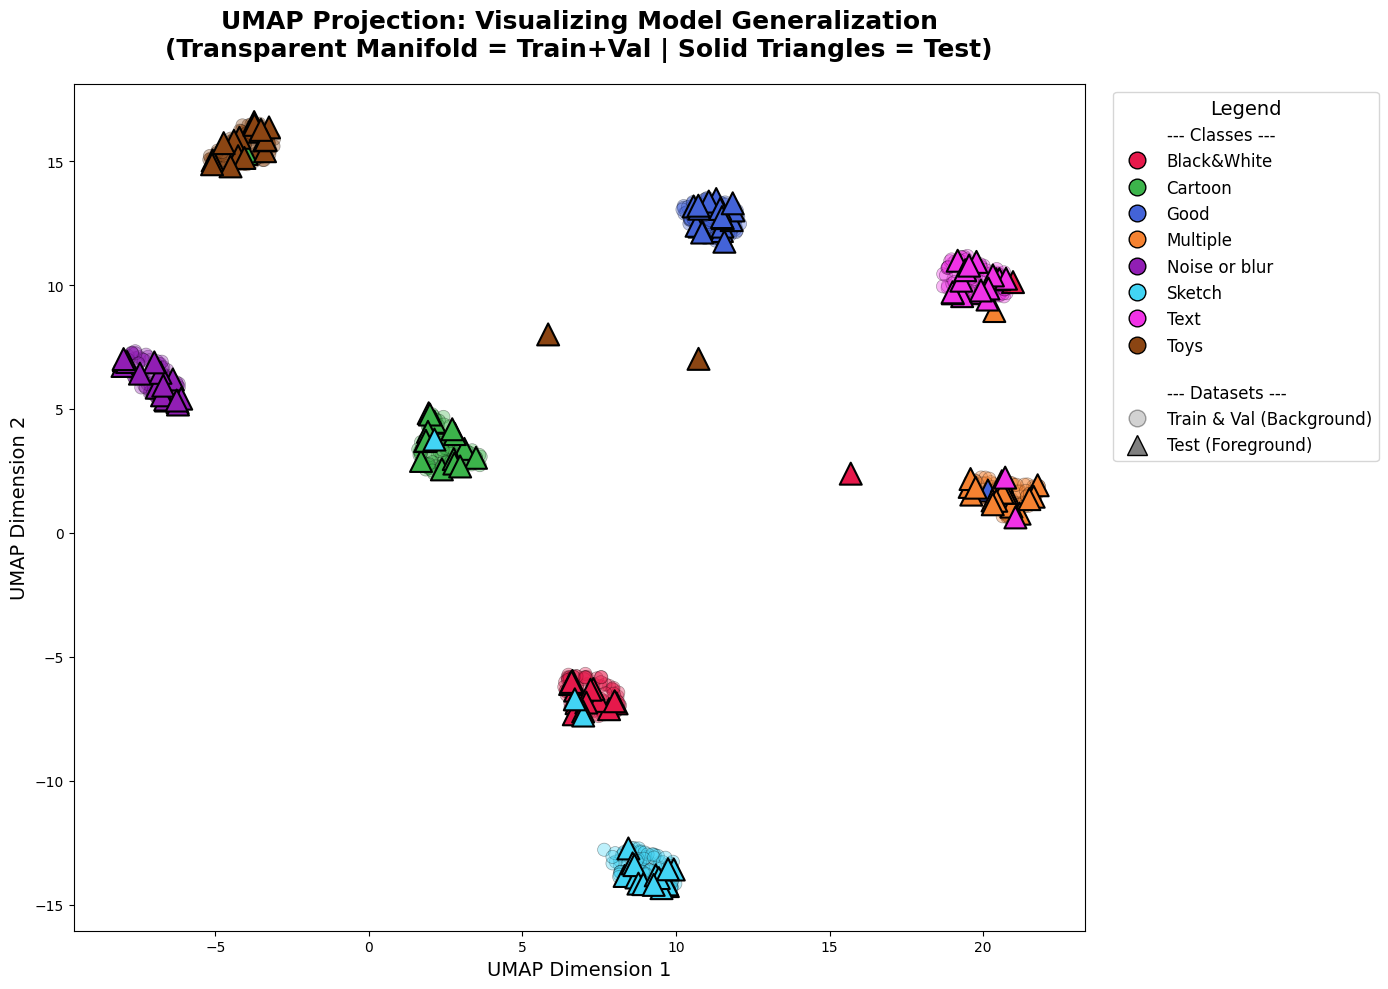

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.lines as mlines

# ==========================================
# 0. איחוד Train ו-Val לסט אחד והכנת הצבעים
# ==========================================
final_umap_df['Set'] = final_umap_df['Set'].replace({'Train': 'Train+Val', 'Val': 'Train+Val'})

# פלטת 8 צבעים מובחנים ורחוקים זה מזה לחלוטין
distinct_colors = [
    '#E6194B', # אדום
    '#3CB44B', # ירוק
    '#4363D8', # כחול
    '#F58231', # כתום
    '#911EB4', # סגול
    '#42D4F4', # תכלת/ציאן
    '#F032E6', # מגנטה/ורוד זוהר
    '#8B4513'  # חום (במקום צהוב שקשה לראות על רקע לבן)
]
classes = sorted(final_umap_df['Class'].unique())
color_map = {cls: distinct_colors[i % len(distinct_colors)] for i, cls in enumerate(classes)}

# ==========================================
# 1. יצירת גרף אינטראקטיבי (HTML)
# ==========================================
fig = px.scatter(
    final_umap_df, x='UMAP_X', y='UMAP_Y', color='Class',
    symbol='Set', symbol_map={'Train+Val': 'circle', 'Test': 'triangle-up'},
    color_discrete_map=color_map, hover_data=['Filename'],
    title='UMAP Projection: Manifold (Train+Val) vs. Generalization (Test)'
)

# החזרת קווי המתאר השחורים לכל הנקודות
fig.for_each_trace(lambda trace: trace.update(
    marker=dict(
        size=12 if 'Test' in trace.name else 8,
        opacity=1.0 if 'Test' in trace.name else 0.4,
        line=dict(width=1, color='black') # קו מתאר שחור לכולם
    )
))

html_filename = "UMAP_Interactive_Final.html"
fig.write_html(html_filename)
print(f"✅ נשמר קובץ אינטראקטיבי מעודכן: {html_filename}")

# ==========================================
# 2. יצירת גרף סטטי לפוסטר (עם קווי מתאר)
# ==========================================
plt.figure(figsize=(14, 10))

# שכבה 1: Train+Val (רקע חצי-שקוף עם קו מתאר עדין)
sns.scatterplot(
    data=final_umap_df[final_umap_df['Set'] == 'Train+Val'],
    x='UMAP_X', y='UMAP_Y', hue='Class', palette=color_map,
    marker='o', s=90, alpha=0.35, edgecolor='black', linewidth=0.5, legend=False, zorder=1
)

# שכבה 2: Test (אטום לחלוטין עם קו מתאר בולט וברור)
sns.scatterplot(
    data=final_umap_df[final_umap_df['Set'] == 'Test'],
    x='UMAP_X', y='UMAP_Y', hue='Class', palette=color_map,
    marker='^', s=250, alpha=1.0, edgecolor='black', linewidth=1.5, legend=False, zorder=2
)

# עיצוב הכותרות
plt.title("UMAP Projection: Visualizing Model Generalization\n(Transparent Manifold = Train+Val | Solid Triangles = Test)", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("UMAP Dimension 1", fontsize=14)
plt.ylabel("UMAP Dimension 2", fontsize=14)

# בניית המקרא
legend_elements = []
legend_elements.append(mlines.Line2D([], [], color='none', label='--- Classes ---'))
for cls, color in color_map.items():
    legend_elements.append(mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markeredgecolor='black', markersize=12, label=cls))

legend_elements.append(mlines.Line2D([], [], color='none', label='\n--- Datasets ---'))
legend_elements.append(mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black', alpha=0.35, markersize=12, label='Train & Val (Background)'))
legend_elements.append(mlines.Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=14, label='Test (Foreground)'))

plt.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', title="Legend", fontsize=12, title_fontsize=14)
plt.tight_layout()

# שמירה להדפסה
poster_filename = "UMAP_Poster_Final.png"
plt.savefig(poster_filename, dpi=300, bbox_inches='tight')
print(f"✅ נשמרה תמונת פוסטר: {poster_filename}")

plt.show()

✅ נשמר קובץ אינטראקטיבי מעודכן: UMAP_Interactive_improved.html
✅ נשמרה תמונת פוסטר: UMAP_Poster_improved.png


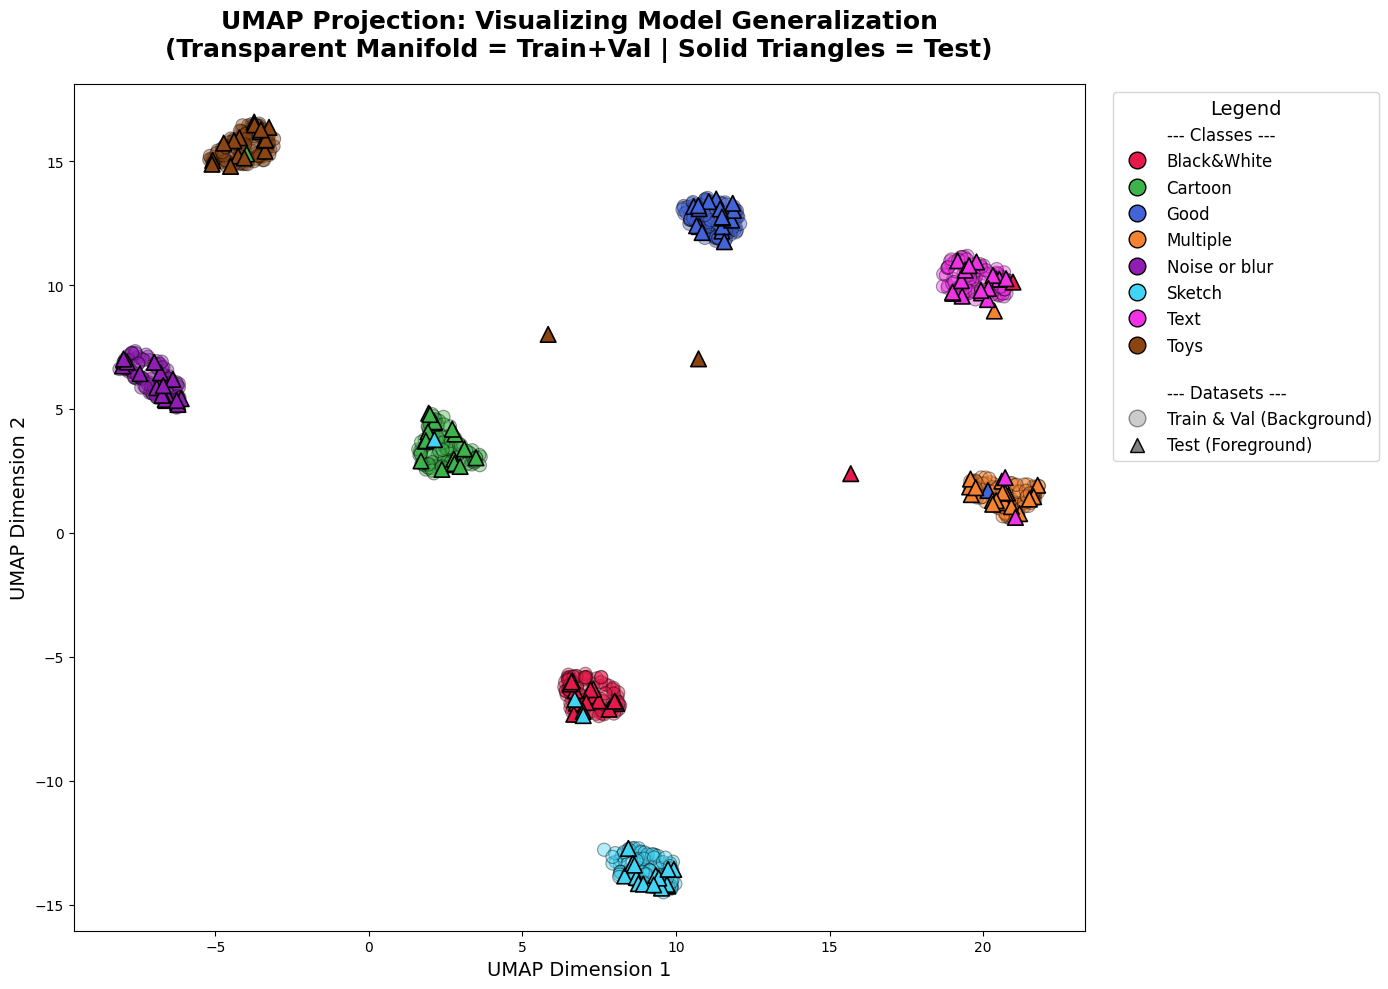

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.lines as mlines

# ==========================================
# 0. איחוד Train ו-Val לסט אחד והכנת הצבעים
# ==========================================
final_umap_df['Set'] = final_umap_df['Set'].replace({'Train': 'Train+Val', 'Val': 'Train+Val'})

# פלטת 8 צבעים מובחנים ורחוקים זה מזה לחלוטין
distinct_colors = [
    '#E6194B', # אדום
    '#3CB44B', # ירוק
    '#4363D8', # כחול
    '#F58231', # כתום
    '#911EB4', # סגול
    '#42D4F4', # תכלת/ציאן
    '#F032E6', # מגנטה/ורוד זוהר
    '#8B4513'  # חום
]
classes = sorted(final_umap_df['Class'].unique())
color_map = {cls: distinct_colors[i % len(distinct_colors)] for i, cls in enumerate(classes)}

# ==========================================
# 1. יצירת גרף אינטראקטיבי (HTML)
# ==========================================
fig = px.scatter(
    final_umap_df, x='UMAP_X', y='UMAP_Y', color='Class',
    symbol='Set', symbol_map={'Train+Val': 'circle', 'Test': 'triangle-up'},
    color_discrete_map=color_map, hover_data=['Filename'],
    title='UMAP Projection: Manifold (Train+Val) vs. Generalization (Test)'
)

# הקטנת סמלי הטסט פי 2 (מ-12 ל-6) וקו מתאר שחור לכולם
fig.for_each_trace(lambda trace: trace.update(
    marker=dict(
        size=6 if 'Test' in trace.name else 7,
        opacity=1.0 if 'Test' in trace.name else 0.4,
        line=dict(width=1, color='black') # קו מתאר שחור מודגש לכל הנקודות
    )
))

html_filename = "UMAP_Interactive_improved.html"
fig.write_html(html_filename)
print(f"✅ נשמר קובץ אינטראקטיבי מעודכן: {html_filename}")

# ==========================================
# 2. יצירת גרף סטטי לפוסטר
# ==========================================
plt.figure(figsize=(14, 10))

# שכבה 1: Train+Val (קו מתאר שחור בולט גם תחת שקיפות)
sns.scatterplot(
    data=final_umap_df[final_umap_df['Set'] == 'Train+Val'],
    x='UMAP_X', y='UMAP_Y', hue='Class', palette=color_map,
    marker='o', s=90, alpha=0.4, edgecolor='black', linewidth=0.8, legend=False, zorder=1
)

# שכבה 2: Test (הוקטן פי 2 מ-250 ל-125, קו מתאר שחור בולט)
sns.scatterplot(
    data=final_umap_df[final_umap_df['Set'] == 'Test'],
    x='UMAP_X', y='UMAP_Y', hue='Class', palette=color_map,
    marker='^', s=125, alpha=1.0, edgecolor='black', linewidth=1.2, legend=False, zorder=2
)

# עיצוב הכותרות
plt.title("UMAP Projection: Visualizing Model Generalization\n(Transparent Manifold = Train+Val | Solid Triangles = Test)", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("UMAP Dimension 1", fontsize=14)
plt.ylabel("UMAP Dimension 2", fontsize=14)

# בניית המקרא
legend_elements = []
legend_elements.append(mlines.Line2D([], [], color='none', label='--- Classes ---'))
for cls, color in color_map.items():
    legend_elements.append(mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markeredgecolor='black', markersize=12, label=cls))

legend_elements.append(mlines.Line2D([], [], color='none', label='\n--- Datasets ---'))
legend_elements.append(mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black', alpha=0.4, markersize=12, label='Train & Val (Background)'))
legend_elements.append(mlines.Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=10, label='Test (Foreground)'))

plt.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', title="Legend", fontsize=12, title_fontsize=14)
plt.tight_layout()

# שמירה להדפסה
poster_filename = "UMAP_Poster_improved.png"
plt.savefig(poster_filename, dpi=300, bbox_inches='tight')
print(f"✅ נשמרה תמונת פוסטר: {poster_filename}")

plt.show()

✅ נשמר קובץ אינטראקטיבי מעודכן: UMAP_Interactive_imp.html
✅ נשמרה תמונת פוסטר: UMAP_Poster_imp.png


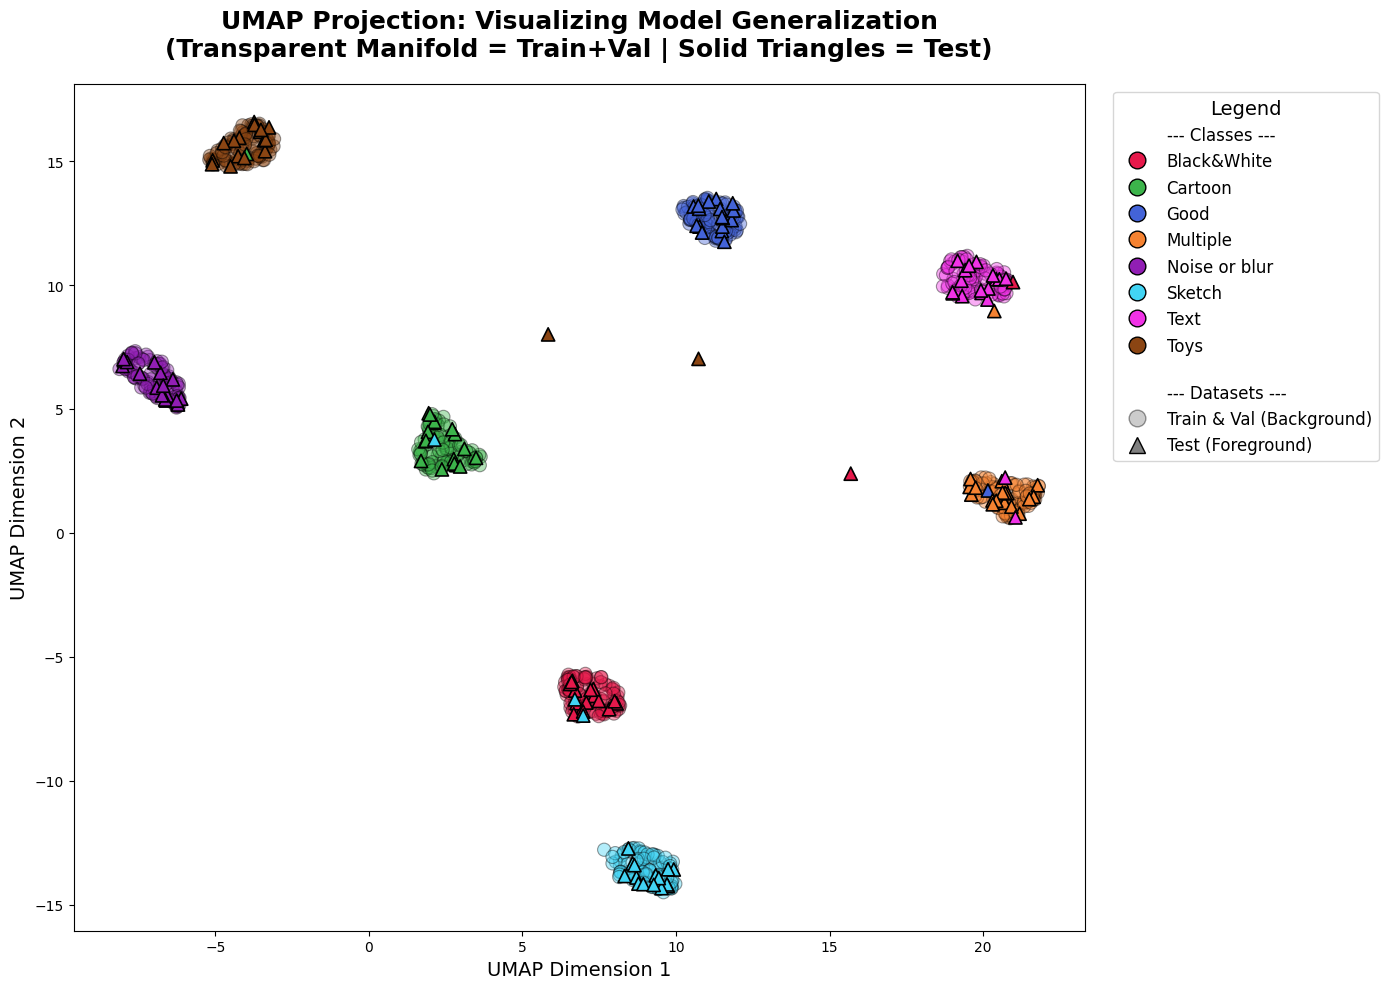

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.lines as mlines

# ==========================================
# 0. איחוד Train ו-Val לסט אחד והכנת הצבעים
# ==========================================
final_umap_df['Set'] = final_umap_df['Set'].replace({'Train': 'Train+Val', 'Val': 'Train+Val'})

# פלטת 8 צבעים מובחנים ורחוקים זה מזה לחלוטין
distinct_colors = [
    '#E6194B', # אדום
    '#3CB44B', # ירוק
    '#4363D8', # כחול
    '#F58231', # כתום
    '#911EB4', # סגול
    '#42D4F4', # תכלת/ציאן
    '#F032E6', # מגנטה/ורוד זוהר
    '#8B4513'  # חום
]
classes = sorted(final_umap_df['Class'].unique())
color_map = {cls: distinct_colors[i % len(distinct_colors)] for i, cls in enumerate(classes)}

# ==========================================
# 1. יצירת גרף אינטראקטיבי (HTML)
# ==========================================
fig = px.scatter(
    final_umap_df, x='UMAP_X', y='UMAP_Y', color='Class',
    symbol='Set', symbol_map={'Train+Val': 'circle', 'Test': 'triangle-up'},
    color_discrete_map=color_map, hover_data=['Filename'],
    title='UMAP Projection: Manifold (Train+Val) vs. Generalization (Test)'
)

# השוואת סמלים: משולשים ועיגולים באותו גודל בדיוק (7)
fig.for_each_trace(lambda trace: trace.update(
    marker=dict(
        size=7,
        opacity=1.0 if 'Test' in trace.name else 0.4,
        line=dict(width=1, color='black') # קו מתאר שחור מודגש לכל הנקודות
    )
))

html_filename = "UMAP_Interactive_imp.html"
fig.write_html(html_filename)
print(f"✅ נשמר קובץ אינטראקטיבי מעודכן: {html_filename}")

# ==========================================
# 2. יצירת גרף סטטי לפוסטר
# ==========================================
plt.figure(figsize=(14, 10))

# שכבה 1: Train+Val (קו מתאר שחור בולט גם תחת שקיפות)
sns.scatterplot(
    data=final_umap_df[final_umap_df['Set'] == 'Train+Val'],
    x='UMAP_X', y='UMAP_Y', hue='Class', palette=color_map,
    marker='o', s=90, alpha=0.4, edgecolor='black', linewidth=0.8, legend=False, zorder=1
)

# שכבה 2: Test (הוקטן ל-90, בדיוק כמו סט האימון, עם קו מתאר שחור בולט)
sns.scatterplot(
    data=final_umap_df[final_umap_df['Set'] == 'Test'],
    x='UMAP_X', y='UMAP_Y', hue='Class', palette=color_map,
    marker='^', s=90, alpha=1.0, edgecolor='black', linewidth=1.2, legend=False, zorder=2
)

# עיצוב הכותרות
plt.title("UMAP Projection: Visualizing Model Generalization\n(Transparent Manifold = Train+Val | Solid Triangles = Test)", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("UMAP Dimension 1", fontsize=14)
plt.ylabel("UMAP Dimension 2", fontsize=14)

# בניית המקרא
legend_elements = []
legend_elements.append(mlines.Line2D([], [], color='none', label='--- Classes ---'))
for cls, color in color_map.items():
    legend_elements.append(mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markeredgecolor='black', markersize=12, label=cls))

legend_elements.append(mlines.Line2D([], [], color='none', label='\n--- Datasets ---'))
legend_elements.append(mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='black', alpha=0.4, markersize=12, label='Train & Val (Background)'))
# התאמת גודל המשולש במקרא לגודל העיגול (12)
legend_elements.append(mlines.Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markeredgecolor='black', markersize=12, label='Test (Foreground)'))

plt.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', title="Legend", fontsize=12, title_fontsize=14)
plt.tight_layout()

# שמירה להדפסה
poster_filename = "UMAP_Poster_imp.png"
plt.savefig(poster_filename, dpi=300, bbox_inches='tight')
print(f"✅ נשמרה תמונת פוסטר: {poster_filename}")

plt.show()

In [ ]:
import os
print(os.getcwd())

/users/amit.cohen


In [ ]:
import os
import shutil

# 1. הגדרת שם התיקייה החדשה
folder_name = "UMAPs"

# 2. יצירת התיקייה (אם היא עדיין לא קיימת)
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"📁 תיקייה '{folder_name}' נוצרה בהצלחה!")
else:
    print(f"📁 התיקייה '{folder_name}' כבר קיימת.")

# 3. רשימת הקבצים להעברה
files_to_move = ["UMAP_Poster_imp.png", "UMAP_Interactive_imp.html"]

# 4. העברת הקבצים לתוך התיקייה החדשה
for file in files_to_move:
    # בודק אם הקובץ קיים בתיקייה הראשית
    if os.path.exists(file):
        destination = os.path.join(folder_name, file)
        # שימוש ב-move שדורס קובץ ישן אם הוא כבר קיים שם
        shutil.move(file, destination)
        print(f"✅ הקובץ {file} הועבר בהצלחה לתוך '{folder_name}/'")
    # בודק אולי הוא כבר הועבר לתיקייה בעבר
    elif os.path.exists(os.path.join(folder_name, file)):
        print(f"ℹ️ הקובץ {file} כבר נמצא בתוך '{folder_name}/'")
    else:
        print(f"❌ הקובץ {file} לא נמצא. ודא שהרצת את בלוק הציור קודם.")

📁 תיקייה 'UMAPs' נוצרה בהצלחה!
✅ הקובץ UMAP_Poster_imp.png הועבר בהצלחה לתוך 'UMAPs/'
✅ הקובץ UMAP_Interactive_imp.html הועבר בהצלחה לתוך 'UMAPs/'
